# Geometry
This notebook will teach you how to set your geometry for your magnets. The `geometry` parameter can accept numpy arrays and functions.

In [130]:
import numpy as np
from mumaxplus import Ferromagnet, Grid, World
import mumaxplus.util.shape as shape
import matplotlib.pyplot as plt

We will first define the constants of our world and grid. The grid is comprised of 128 x 64 x 1 cells of each 1 x 1 x 1 nm³.

In [123]:
nx, ny, nz = 128, 64, 1
cx, cy, cz = 1e-9, 1e-9, 1e-9

Now we create a function to visualise the geometry. In the final images empty space will be shown as white while the magnetic material will be gray.

In [124]:
def show_2D_geom(magnet):
    geom = magnet.geometry[0,...]
    im_extent = (-0.5*cx * 1e9, (nx*cx - 0.5*cx) * 1e9, -0.5*cy * 1e9, (ny*cy - 0.5*cy) * 1e9)
    plt.imshow(geom, cmap="Greys", origin="lower", extent=im_extent, vmin=0, vmax=2)
    plt.xlabel("x (nm)")
    plt.ylabel("y (nm)")
    plt.show()

## 1. Numpy arrays
Here we will be looking at setting the geometry with a numpy array. The array should have the same dimensions as our grid and should contain booleans.

### 1.1 The full grid
If we want our magnet to be the entire grid we do not have to specify a geometry.

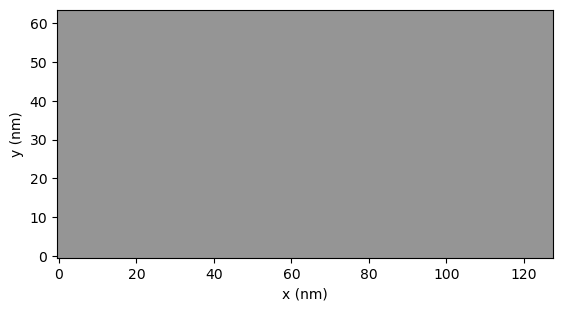

In [125]:
world = World(cellsize=(cx, cy, cz))
grid  = Grid((nx, ny, nz))

magnet = Ferromagnet(world=world, grid=grid)
magnet.magnetization = (1,0,0)

show_2D_geom(magnet)

### 1.2 Eliminating pixels
If we want to remove some pixels from the magnet we can create an array as big as our grid and set some values to 0 (or `False`). Note that the array should have a shape of (nz, ny, nx).
Let's now remove a pixel at the center row of the magnet.

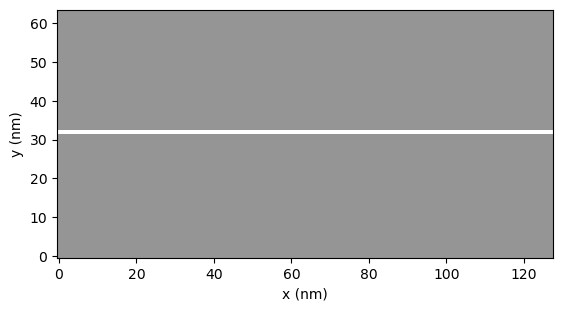

In [126]:
world = World(cellsize=(cx, cy, cz))
grid  = Grid((nx, ny, nz))

geom_array = np.ones(shape=(nz,ny,nx))
geom_array[:,ny//2,:] = 0

magnet = Ferromagnet(world=world, grid=grid, geometry=geom_array)
magnet.magnetization = (1,0,0)

show_2D_geom(magnet)

## 2. Functions

We can also create our own functions to form geometries. The input of every function should be (x,y,z) where x, y and z are real space coordinates. The output of the function should be a boolean.

### 2.1 Circle
Here we create a circle with a radius of 20nm at the center of the grid.

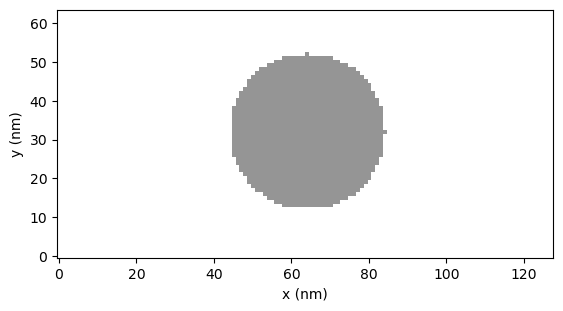

In [ ]:
world = World(cellsize=(cx, cy, cz))
grid  = Grid((nx, ny, nz))

geomfunc = lambda x, y, z: (x-nx*cx/2)**2 + (y-ny*cy/2)**2 < (20e-9)**2

magnet = Ferromagnet(world=world, grid=grid, geometry=geomfunc)
magnet.magnetization = (1,0,0)

show_2D_geom(magnet)

### 2.2 Sawtooth
Here we will cut a sawtooth pattern out of a magnet.

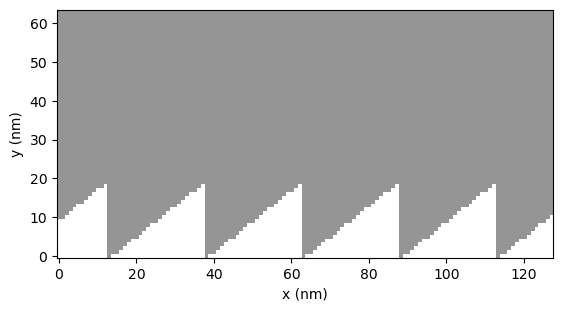

In [128]:
world = World(cellsize=(cx, cy, cz))
grid  = Grid((nx, ny, nz))

p = 25e-9
a = 20e-9

def saw(x,y,z):
    func = a*(x/p - np.floor(0.5 + x/p)) + a/2-cy
    return y > func

magnet = Ferromagnet(world=world, grid=grid, geometry=saw)
magnet.magnetization = (1,0,0)

show_2D_geom(magnet)

## 3. Shapes
Let's end this tutoial by using the `Shape` class to generate a geometry. For more information on different shapes and shape manipulations see `shape.ipynb`.
### 3.1 Sphere
Here we create a circular magnet with a diameter of 60nm.

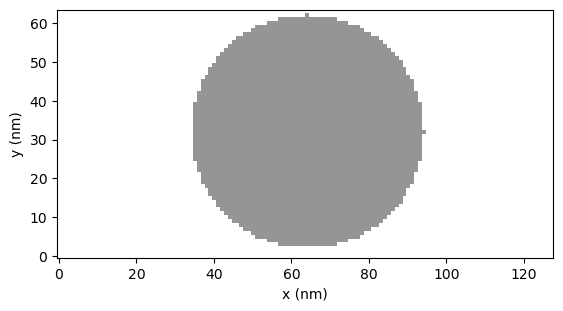

In [129]:
world = World(cellsize=(cx, cy, cz))
grid  = Grid((nx, ny, nz))

circ = shape.Circle(diam=60e-9)
circ.translate(nx*cx/2, ny*cy/2, nz*cz/2)
magnet = Ferromagnet(world=world, grid=grid, geometry=circ)

show_2D_geom(magnet)